# Run DRIMC

In [1]:
import os
import time
import gzip
import pickle
import warnings

%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np

from tqdm import TqdmSynchronisationWarning
warnings.simplefilter("ignore", TqdmSynchronisationWarning)

In [15]:
PATH_ROOT = "/Users/sijianfan/Documents/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/cdataset/cv_data")

PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/realAnalysis/cdataset")
if not os.path.isdir(PATH_OUTPUT):
    os.makedirs(PATH_OUTPUT)

PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
if not os.path.isdir(PATH_ARCHIVE):
    os.makedirs(PATH_ARCHIVE)

In [16]:
filename_staged = os.path.join(PATH_DATA, "staged_dataset.gz")

filenames = {"input": "staged_dataset.gz", "output": "results_drimc.gz"}

In [17]:
filename_input = os.path.join(PATH_DATA, filenames["input"])

filename_output = os.path.join(PATH_OUTPUT, filenames["output"])

if os.path.exists(filename_output):
    mdttm = time.strftime("%Y%m%d_%H%M%S")
    os.rename(
        filename_output,
        os.path.join(PATH_ARCHIVE, "%s%s" % (mdttm, filenames["output"])),
    )

In [18]:
from sgimc.utils import mc_split

In [19]:
from sgimc.utils import get_submatrix

In [20]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sgimc.utils import sparsify_with_mask


def mc_get_scores(R_true, R_prob):
    R_pred = np.where(R_prob.data > 0.5, 1, -1)

    # compute the confusion matrix for ±1 labels (`-1` is negative)
    ii, jj = ((R_pred + 1) // 2).astype(int), ((R_true.data + 1) // 2).astype(int)
    cnfsn = confusion_matrix(y_true=jj, y_pred=ii)

    return {
        "tn": cnfsn[0, 0],
        "fn": cnfsn[1, 0],
        "fp": cnfsn[0, 1],
        "tp": cnfsn[1, 1],
        "auc": roc_auc_score(R_true.data, R_prob.data),
    }

In [21]:
random_state = np.random.RandomState(0x0BADCAFE)

## Import model

In [22]:
import rpy2.robjects as robjects

r = robjects.r

DRIMC_path = "/Users/sijianfan/Documents/projects/BiSSGL/scripts/methods/DRIMC"
r(f'setwd("{DRIMC_path}")')
print(r("getwd()"))

[1] "/Users/sijianfan/Documents/projects/BiSSGL/scripts/methods/DRIMC"



In [23]:
pkgs = ["matrixcalc", "data.table", "Rcpp", "ROCR", "Bolstad2", "MESS"]
rPkgs = [r(f'require("{pkg}", character.only=TRUE)') for pkg in pkgs]

In [24]:
rSourceNames = [
    "doCrossValidationByPairwise.R",
    "doCrossValidationByRow.R",
    "constrNeig.R",
    "inferZeros.R",
    "calcLogLik.R",
    "calcDeriv.R",
    "updateUV.R",
    "calcPredScore.R",
    "calcAUPR.R",
]
rSN = [r(f'source("{r_file}")') for r_file in rSourceNames]

In [25]:
r("library(Rcpp)")
cppSourceNames = [
    "fastKF2.cpp",
    "fastKF4.cpp",
    "fastKgipMat.cpp",
    "log1pexp.cpp",
    "sigmoid.cpp",
]
cppSN = [r(f'sourceCpp("{cpp_file}")') for cpp_file in cppSourceNames]

In [26]:
updateUV = r["updateUV"]

## Load data

In [27]:
from sgimc.utils import load, save

U, V, Y = load(filename_input)

Y = Y.astype(float)

## Without selection

### Prepare similarity matrix

In [ ]:
# Quick prepare of similarity matrix
from sklearn.metrics.pairwise import cosine_similarity

simD = cosine_similarity(U[:, :])
simT = cosine_similarity(V[:, :])

In [131]:
# Jaccard distance → convert to similarity
from sklearn.metrics import pairwise_distances

simD = 1 - pairwise_distances(U.toarray(), metric="jaccard")
simT = 1 - pairwise_distances(V.toarray(), metric="jaccard")

/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/sklearn/metrics/pairwise.py:2182: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/sklearn/metrics/pairwise.py:2182: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [28]:
# Just use no information
simD = np.eye(U.shape[0])
simT = np.eye(V.shape[0])

In [29]:
simD_Robj = r.matrix(
    robjects.FloatVector(simD.flatten()),
    byrow=True,
    nrow=simD.shape[0],
    ncol=simD.shape[0],
)
simT_Robj = r.matrix(
    robjects.FloatVector(simT.flatten()),
    byrow=True,
    nrow=simT.shape[0],
    ncol=simT.shape[0],
)

In [133]:
constrNeig = r["constrNeig"]

In [134]:
# Use neighorhood size K = 3
lap = constrNeig(simD_Robj, simT_Robj, K=3)
simD_Robj, simT_Robj = lap[2], lap[3]
simD, simT = np.array(simD), np.array(simT)

In [135]:
simD.shape, simT.shape

((6949, 6949), (13, 13))

### Implementation

In [30]:
dvlp_size, test_size = 0.9, 0.1

ind_dvlp, ind_test = next(
    mc_split(
        Y,
        n_splits=1,
        random_state=random_state,
        train_size=dvlp_size,
        test_size=test_size,
    )
)

Y_test = get_submatrix(Y, ind_test)

In [60]:
from sklearn.model_selection import ParameterGrid

grid_dataset = ParameterGrid(
    {
        # "train_size": np.arange(0.001, 0.2, 0.02),
        "train_size": [0.89],
        "n_splits": [2],
    }
)

grid_model = ParameterGrid(
    {
        "lamU": [2],
        "lamV": [2],
        # "cc": [1, 3, 5, 7, 9],  # confidence parameter
        "cc": [10],
        "iterpara": [0.125],  # learning rate
        "numLat": [200],  # rank
    }
)

In [61]:
from tqdm import tqdm
from sklearn.model_selection import ShuffleSplit, KFold
from sklearn.model_selection import train_test_split
from scipy.special import expit


results = []
for par_dtst in tqdm(grid_dataset):
    # prepare the train dataset: take the specified share from the beginnig of the index array
    ind_train_all, _ = train_test_split(
        ind_dvlp,
        shuffle=False,
        random_state=random_state,
        test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
    )

    # Run the experiment: the model
    for par_mdl in grid_model:  # tqdm.tqdm(, desc="cv %02d" % (cv,))
        Y_train = get_submatrix(Y, ind_train_all)

        # Y_train[Y_train == 0] = 0.5
        Y_train[Y_train == -1] = 0.0

        Y_train_Robj = r.matrix(
            robjects.FloatVector(Y_train.toarray().flatten()),
            byrow=True,
            nrow=Y_train.shape[0],
            ncol=Y_train.shape[1],
        )

        # set up the model
        lamU, lamV, cc, iterpara, numLat = (
            par_mdl["lamU"],
            par_mdl["lamV"],
            par_mdl["cc"],
            par_mdl["iterpara"],
            par_mdl["numLat"],
        )

        out = updateUV(
            cc=cc,
            inMat=Y_train_Robj,
            Sd=simD_Robj,
            St=simT_Robj,
            lamU=lamU,
            lamV=lamV,
            numLat=numLat,
            initMethod="useSeed",
            thisSeed=123,
            iterpara=iterpara,
            maxIter=100,
        )

        # fit on the whole development dataset
        est_A, est_B = np.array(out[0]), np.array(out[1])

        # get the score
        prob_full = expit(simD @ est_A @ est_B.T @ simT.T)
        prob_test = get_submatrix(prob_full, ind_test)
        scores_test = mc_get_scores(Y_test, prob_test)
        d1_test = sum(abs(est_A).max(axis=1) > 0)
        d2_test = sum(abs(est_B).max(axis=1) > 0)

        # record the results
        results.append(
            {
                "train_size": par_dtst["train_size"],
                "lamU": par_mdl["lamU"],
                "lamV": par_mdl["lamV"],
                "cc": par_mdl["cc"],
                "iterpara": par_mdl["iterpara"],
                "numLat": par_mdl["numLat"],
                "test_score": scores_test["auc"],
                "test_d1": d1_test,
                "test_d2": d2_test,
            }
        )

100%|██████████| 1/1 [00:01<00:00,  1.09s/it]


([<matplotlib.lines.Line2D at 0x135bf5dd0>],
 [{'train_size': 0.89,
   'lamU': 2,
   'lamV': 2,
   'cc': 10,
   'iterpara': 0.125,
   'numLat': 200,
   'test_score': 0.9021029255461596,
   'test_d1': 409,
   'test_d2': 658}])

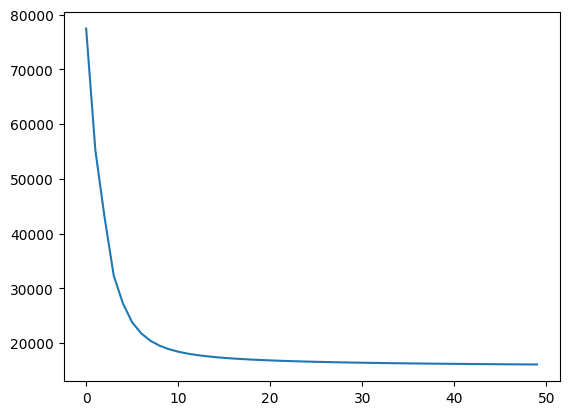

In [62]:
plt.plot(out[3]), results  # 0.797701913983849

In [39]:
filename_output

'/Users/sijianfan/Documents/projects/BiSSGL/outputs/results/realAnalysis/cdataset/results_drimc.gz'

In [141]:
with gzip.open(filename_output, "wb+", 4) as fout:
    pickle.dump(results, fout)

---

## With selection

In [ ]:
from sgimc import SparseGroupIMCClassifier

C_lasso, C_group, C_ridge, rank = (0.0, 1.0, 1.0, 13)

imc = SparseGroupIMCClassifier(
    rank,
    n_threads=8,
    random_state=42,
    C_lasso=C_lasso,
    C_group=C_group,
    C_ridge=C_ridge,
)

# fit on the whole development dataset
Y_train = get_submatrix(Y, ind_train_all)
imc.fit(U, V, Y_train)

# get the score
prob_full = imc.predict_proba(U, V)
prob_test = get_submatrix(prob_full, ind_test)
scores_test = mc_get_scores(Y_test, prob_test)
d1_test = sum(abs(imc.coef_W_).max(axis=1) > 0)
d2_test = sum(abs(imc.coef_H_).max(axis=1) > 0)

print(scores_test, d1_test, d2_test)

{'tn': 5355, 'fn': 412, 'fp': 308, 'tp': 2959, 'auc': 0.9669303880105017} 1360 22


### Prepare similarity matrix

In [ ]:
# Jaccard distance → convert to similarity
from sklearn.metrics import pairwise_distances

simD = 1 - pairwise_distances(
    U[:, np.where(abs(imc.coef_W_).max(axis=1) > 0)[0]].toarray(), metric="jaccard"
)
simT = 1 - pairwise_distances(
    V[:, np.where(abs(imc.coef_H_).max(axis=1) > 0)[0]].toarray(), metric="jaccard"
)

/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/sklearn/metrics/pairwise.py:2182: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/sklearn/metrics/pairwise.py:2182: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [159]:
simD_Robj = r.matrix(
    robjects.FloatVector(simD.flatten()),
    byrow=True,
    nrow=simD.shape[0],
    ncol=simD.shape[0],
)
simT_Robj = r.matrix(
    robjects.FloatVector(simT.flatten()),
    byrow=True,
    nrow=simT.shape[0],
    ncol=simT.shape[0],
)

In [ ]:
constrNeig = r["constrNeig"]

In [ ]:
# Use neighorhood size K = 3
lap = constrNeig(simD_Robj, simT_Robj, K=3)
simD_Robj, simT_Robj = lap[2], lap[3]
simD, simT = np.array(simD), np.array(simT)

### Implementation

In [189]:
dvlp_size, test_size = 0.9, 0.1

ind_dvlp, ind_test = next(
    mc_split(
        Y,
        n_splits=1,
        random_state=random_state,
        train_size=dvlp_size,
        test_size=test_size,
    )
)

Y_test = get_submatrix(Y, ind_test)

In [190]:
from sklearn.model_selection import ParameterGrid

grid_dataset = ParameterGrid(
    {
        "train_size": np.arange(0.001, 0.2, 0.02),
        # "train_size": [0.2],
        "n_splits": [2],
    }
)

grid_model = ParameterGrid(
    {
        "lamU": [0.01],
        "lamV": [0.01],
        "cc": [1, 3, 5, 7, 9],  # confidence parameter
        # "cc": [1],
        "iterpara": [0.001],  # learning rate
        "numLat": [1000],  # rank
    }
)

Notes:

- lamU and lamV doesn't effect too much here. 

- Main effects come from iterpara and numLat. 

In [191]:
from tqdm import tqdm
from sklearn.model_selection import ShuffleSplit, KFold
from sklearn.model_selection import train_test_split
from scipy.special import expit


results = []
for par_dtst in tqdm(grid_dataset):
    # prepare the train dataset: take the specified share from the beginnig of the index array
    ind_train_all, _ = train_test_split(
        ind_dvlp,
        shuffle=False,
        random_state=random_state,
        test_size=(1 - (par_dtst["train_size"] / dvlp_size)),
    )

    # Run the experiment: the model
    for par_mdl in grid_model:  # tqdm.tqdm(, desc="cv %02d" % (cv,))
        Y_train = get_submatrix(Y, ind_train_all)

        Y_train[Y_train == 0] = 0.5
        Y_train[Y_train == -1] = 0.0

        Y_train_Robj = r.matrix(
            robjects.FloatVector(Y_train.toarray().flatten()),
            byrow=True,
            nrow=Y_train.shape[0],
            ncol=Y_train.shape[1],
        )

        # set up the model
        lamU, lamV, cc, iterpara, numLat = (
            par_mdl["lamU"],
            par_mdl["lamV"],
            par_mdl["cc"],
            par_mdl["iterpara"],
            par_mdl["numLat"],
        )

        out = updateUV(
            cc=cc,
            inMat=Y_train_Robj,
            Sd=simD_Robj,
            St=simT_Robj,
            lamU=lamU,
            lamV=lamV,
            numLat=numLat,
            initMethod="useSeed",
            thisSeed=123,
            iterpara=iterpara,
            maxIter=100,
        )

        # fit on the whole development dataset
        est_A, est_B = np.array(out[0]), np.array(out[1])

        # get the score
        prob_full = expit(simD @ est_A @ est_B.T @ simT.T)
        prob_test = get_submatrix(prob_full, ind_test)
        scores_test = mc_get_scores(Y_test, prob_test)
        d1_test = sum(abs(est_A).max(axis=1) > 0)
        d2_test = sum(abs(est_B).max(axis=1) > 0)

        # record the results
        results.append(
            {
                "train_size": par_dtst["train_size"],
                "lamU": par_mdl["lamU"],
                "lamV": par_mdl["lamV"],
                "cc": par_mdl["cc"],
                "iterpara": par_mdl["iterpara"],
                "numLat": par_mdl["numLat"],
                "test_score": scores_test["auc"],
                "test_d1": d1_test,
                "test_d2": d2_test,
            }
        )

  0%|          | 0/10 [00:00<?, ?it/s]/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3699: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3699: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/sijianfan/.pyenv/versions/BiSSGL_venv_311/lib/python3.11/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity struc

([<matplotlib.lines.Line2D at 0x1369a2610>],
 [{'train_size': 0.001,
   'lamU': 0.01,
   'lamV': 0.01,
   'cc': 1,
   'iterpara': 0.001,
   'numLat': 1000,
   'test_score': 0.48041593756598494,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lamU': 0.01,
   'lamV': 0.01,
   'cc': 3,
   'iterpara': 0.001,
   'numLat': 1000,
   'test_score': 0.33341079048102873,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lamU': 0.01,
   'lamV': 0.01,
   'cc': 5,
   'iterpara': 0.001,
   'numLat': 1000,
   'test_score': 0.5382657125116812,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lamU': 0.01,
   'lamV': 0.01,
   'cc': 7,
   'iterpara': 0.001,
   'numLat': 1000,
   'test_score': 0.30293307535190217,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 0.001,
   'lamU': 0.01,
   'lamV': 0.01,
   'cc': 9,
   'iterpara': 0.001,
   'numLat': 1000,
   'test_score': 0.3113344580821986,
   'test_d1': 6949,
   'test_d2': 13},
  {'train_size': 

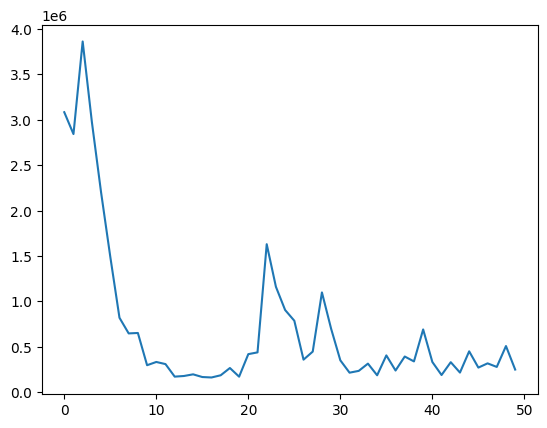

In [192]:
plt.plot(out[3]), results  # 0.797701913983849

In [193]:
filename_output

'/Users/sijianfan/Documents/projects/BiSSGL/outputs/results/realAnalysis/tuberculosis/results_drimc.gz'

In [194]:
with gzip.open(filename_output, "wb+", 4) as fout:
    pickle.dump(results, fout)